In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GroupKFold

# 1. Data load

In [2]:
# columns for process
PHYS_FEATURES = [
    # HR (6)
    'HR_TD_Mean', 'HR_TD_std', 'HR_TD_Slope',
    'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew',
    # TEMP (5)
    'TEMP_TD_Mean', 'TEMP_TD_Slope', 'TEMP_TD_AUC',
    'TEMP_TD_Kurtosis', 'TEMP_TD_Skew',
    # EDA Phasic (7)
    'EDA_TD_P_Mean', 'EDA_TD_P_std', 'EDA_TD_P_Slope',
    'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT', 'EDA_TD_P_Skew',
    # EDA Tonic (4)
    'EDA_TD_T_Mean', 'EDA_TD_T_Slope',
    'EDA_TD_T_Kurtosis', 'EDA_TD_T_Skew',
]

QUEST_FEATURES = [
    'Frustrated', 'upset', 'hostile', 'alert', 'ashamed',
    'inspired', 'nervous', 'determined', 'attentive', 'afraid', 'active'
]

In [ ]:
df = pd.read_csv('data_0425.csv')

X = df[PHYS_FEATURES].values 
Y = df[QUEST_FEATURES]
Y.isnull().sum()

Frustrated    0
upset         0
hostile       0
alert         0
ashamed       0
inspired      2
nervous       0
determined    2
attentive     1
afraid        1
active        1
dtype: int64

In [13]:
# load data
df = pd.read_csv('F:/DTU/02582 Computational Data Analysis/case2/preprocess/data_0425.csv')

X = df[PHYS_FEATURES].values            

# impute missing values
Y_filled = df.groupby('Individual')[QUEST_FEATURES].transform(
    lambda x: x.fillna(x.mean())
)
Y_filled = Y_filled.fillna(Y_filled.mean())

assert Y_filled.isna().sum().sum() == 0, "Still has NaN after imputation"

Y_raw = Y_filled.values

Y_global = StandardScaler().fit_transform(Y_raw)

def per_subject_zscore(Y_df, group_col):
    def safe_z(x):
        s = x.std()
        if s == 0 or np.isnan(s):
            return x - x.mean()  
        return (x - x.mean()) / s
    return Y_df.groupby(group_col).transform(safe_z)

Y_per_subj = per_subject_zscore(df[QUEST_FEATURES], df['Individual']).values
Y_per_subj = np.nan_to_num(Y_per_subj, nan=0.0)

groups = df['Individual'].values
phase  = df['Phase'].values
round_ = df['Round'].values

assert np.isfinite(X).all(), "Non-finite values in X — check per-subject std==0 cases"
assert np.isfinite(Y_per_subj).all(), "Non-finite values in Y"


# 2. Method

## 2.1 PCA

In [26]:
pca = PCA()
X_pca = pca.fit_transform(X)
evr = pca.explained_variance_ratio_
cumvar = np.cumsum(evr)


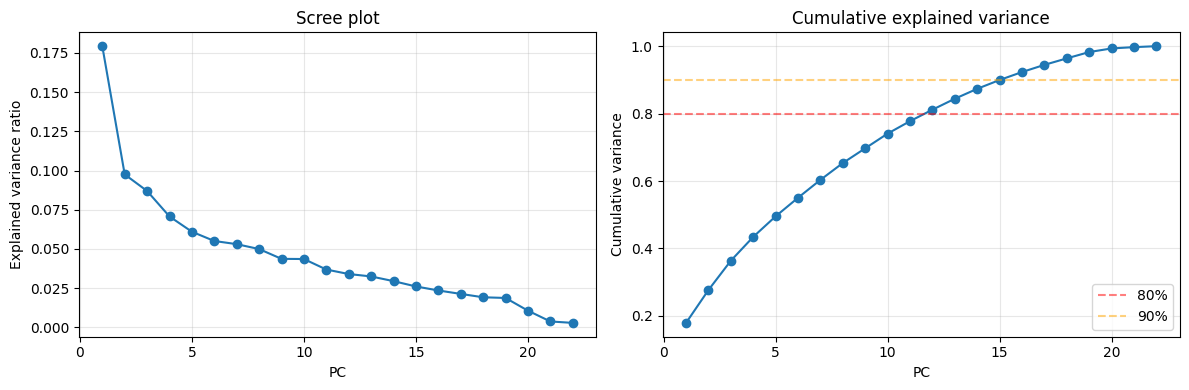

[PCA] PCs needed for 80% variance: 12
[PCA] PCs needed for 90% variance: 16
[PCA] First 5 PCs explain: 49.5%


In [ ]:
# explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(evr) + 1), evr, 'o-')
axes[0].set(xlabel='PC', ylabel='Explained variance ratio', title='Scree plot')
axes[0].grid(alpha=0.3)
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'o-')
axes[1].axhline(0.8, ls='--', c='r', alpha=0.5, label='80%')
axes[1].axhline(0.9, ls='--', c='orange', alpha=0.5, label='90%')
axes[1].set(xlabel='PC', ylabel='Cumulative variance',
            title='Cumulative explained variance')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('pca_scree.png', dpi=150); plt.show()

n_pc_80 = int(np.argmax(cumvar >= 0.8)) + 1
n_pc_90 = int(np.argmax(cumvar >= 0.9)) + 1
print(f"[PCA] PCs needed for 80% variance: {n_pc_80}")
print(f"[PCA] PCs needed for 90% variance: {n_pc_90}")
print(f"[PCA] First 5 PCs explain: {cumvar[4] * 100:.1f}%")

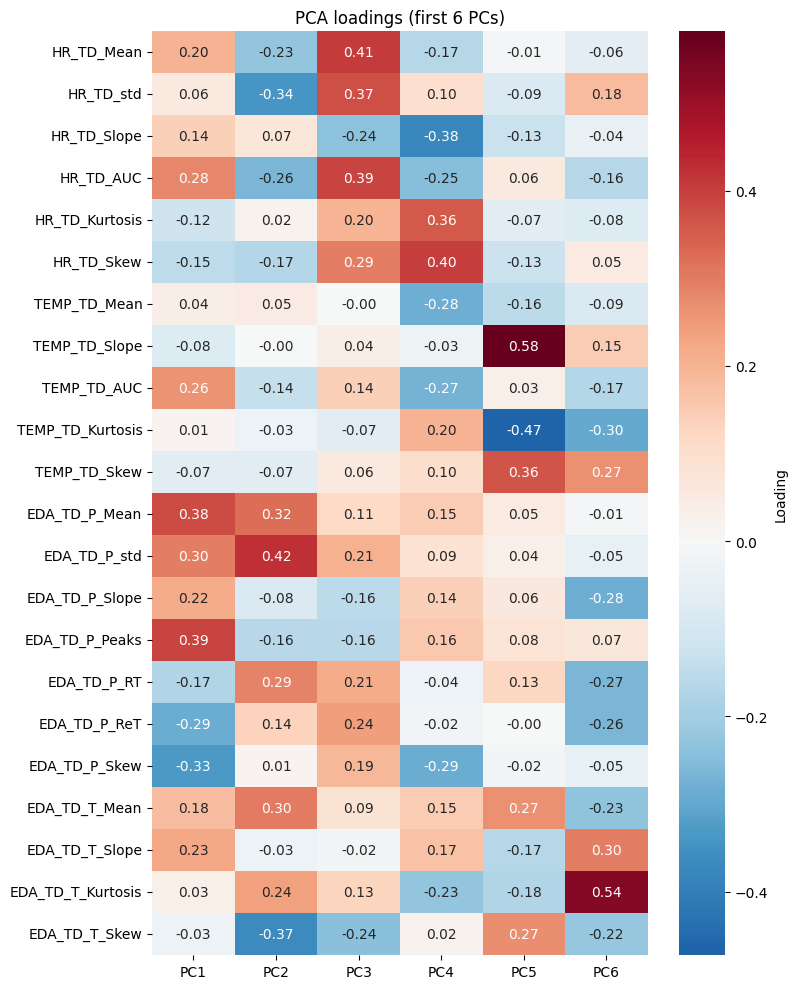

In [ ]:
# heatmap loading of top 6 PCs
n_show = 6
loadings = pd.DataFrame(
    pca.components_[:n_show].T,
    index=PHYS_FEATURES,
    columns=[f'PC{i+1}' for i in range(n_show)]
)
plt.figure(figsize=(8, 10))
sns.heatmap(loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'Loading'})
plt.title(f'PCA loadings (first {n_show} PCs)')
plt.tight_layout(); plt.savefig('pca_loadings.png', dpi=150); plt.show()

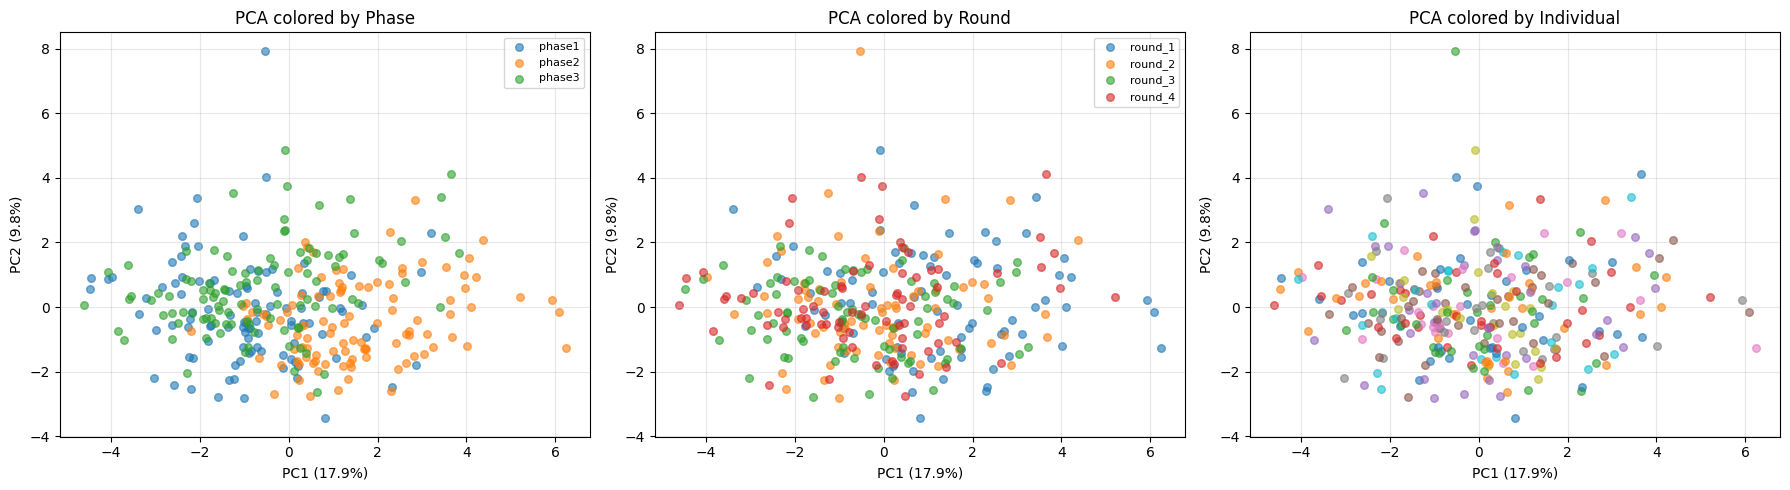

In [ ]:
# PCA projection colored by 3 methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, color_var, title in zip(
    axes, [phase, round_, groups], ['Phase', 'Round', 'Individual']
):
    for val in np.unique(color_var):
        mask = color_var == val
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=str(val), alpha=0.6, s=30)
    ax.set(xlabel=f'PC1 ({evr[0]*100:.1f}%)',
           ylabel=f'PC2 ({evr[1]*100:.1f}%)',
           title=f'PCA colored by {title}')
    if title != 'Individual':        
        ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('pca_projection.png', dpi=150); plt.show()

In [ ]:
def evaluate_representation(Z, labels, groups, name='', k=5):
    """Silhouette + GroupKFold kNN accuracy for a representation Z."""
    sil = silhouette_score(Z, labels)
    knn = KNeighborsClassifier(n_neighbors=k)
    cv = GroupKFold(n_splits=5)
    acc = cross_val_score(knn, Z, labels, groups=groups, cv=cv).mean()
    print(f"  {name:25s}  silhouette={sil:+.3f}   GroupKFold kNN acc={acc:.3f}")
    return sil, acc

print("\n[PCA] Phase separation across representations:")
evaluate_representation(X,                    phase, groups, name='Raw 22D')
evaluate_representation(X_pca[:, :2],         phase, groups, name='PCA 2D')
evaluate_representation(X_pca[:, :5],         phase, groups, name='PCA 5D')
evaluate_representation(X_pca[:, :n_pc_80],   phase, groups, name=f'PCA {n_pc_80}D (80% var)')


[PCA] Phase separation across representations:
  Raw 22D                    silhouette=+0.019   GroupKFold kNN acc=0.509
  PCA 2D                     silhouette=+0.040   GroupKFold kNN acc=0.524
  PCA 5D                     silhouette=+0.028   GroupKFold kNN acc=0.489
  PCA 12D (80% var)          silhouette=+0.022   GroupKFold kNN acc=0.510


(np.float64(0.022137931435390626), np.float64(0.51))

In [ ]:
phase_binary = np.where(phase == 'phase2', 'puzzle', 'rest')
print("\n[PCA] Puzzle vs Rest separation:")
evaluate_representation(X,             phase_binary, groups, name='Raw 22D')
evaluate_representation(X_pca[:, :2],  phase_binary, groups, name='PCA 2D')
evaluate_representation(X_pca[:, :5],  phase_binary, groups, name='PCA 5D')


[PCA] Puzzle vs Rest separation:
  Raw 22D                    silhouette=+0.050   GroupKFold kNN acc=0.773
  PCA 2D                     silhouette=+0.186   GroupKFold kNN acc=0.792
  PCA 5D                     silhouette=+0.106   GroupKFold kNN acc=0.760


(np.float64(0.10635541019202116), np.float64(0.76))

## 2.2 CCA

In [14]:
n_components = 3
cca = CCA(n_components=n_components, max_iter=2000)
cca.fit(X, Y)
X_c, Y_c = cca.transform(X, Y_per_subj)

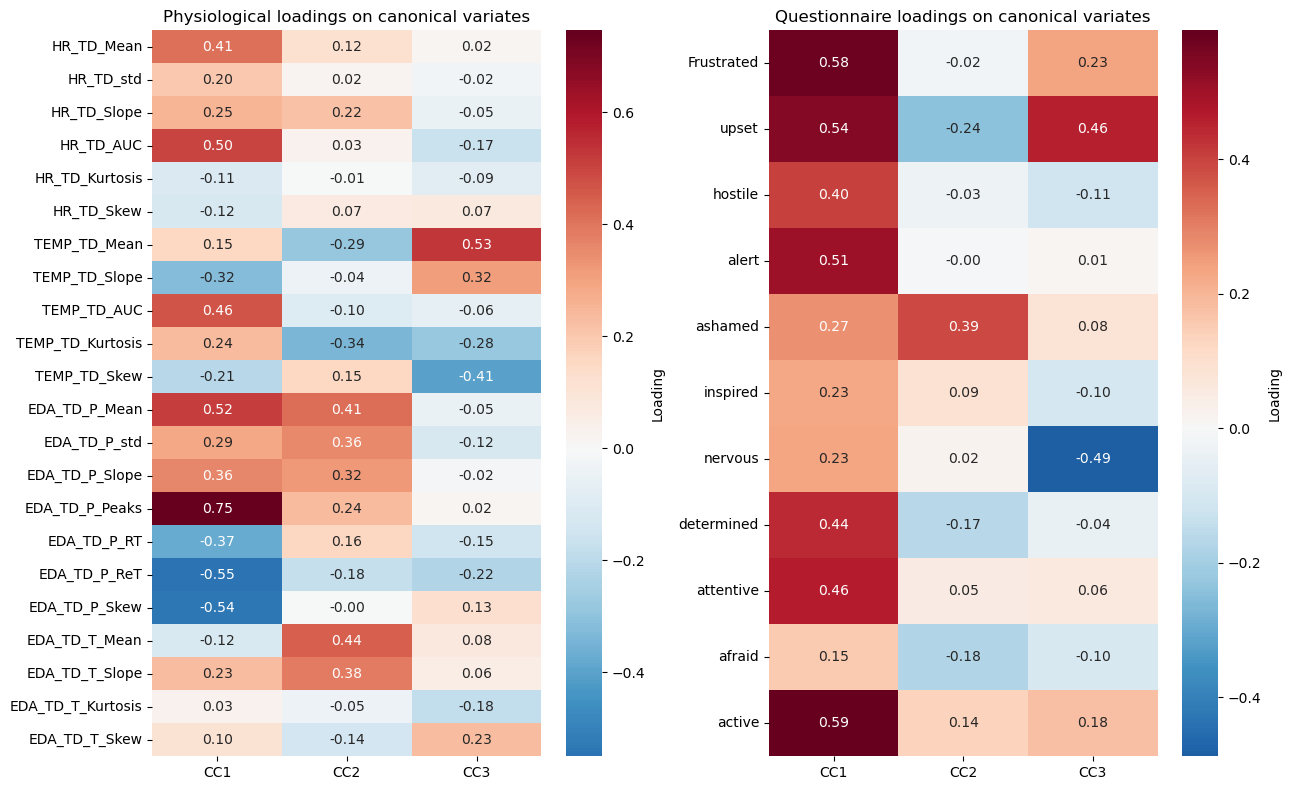

In [17]:
# Canonical loadings
def canonical_loadings(M, M_c, feature_names):
    arr = np.array([[np.corrcoef(M[:, i], M_c[:, j])[0, 1]
                     for j in range(M_c.shape[1])]
                    for i in range(M.shape[1])])
    return pd.DataFrame(arr, index=feature_names,
                        columns=[f'CC{j+1}' for j in range(M_c.shape[1])])

x_load = canonical_loadings(X, X_c, PHYS_FEATURES)
y_load = canonical_loadings(Y, Y_c, QUEST_FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(13, 8),
                         gridspec_kw={'width_ratios': [1, 1]})
sns.heatmap(x_load, cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=axes[0],
            cbar_kws={'label': 'Loading'})
axes[0].set_title('Physiological loadings on canonical variates')
sns.heatmap(y_load, cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=axes[1],
            cbar_kws={'label': 'Loading'})
axes[1].set_title('Questionnaire loadings on canonical variates')
plt.tight_layout(); plt.savefig('cca_loadings.png', dpi=150); plt.show()

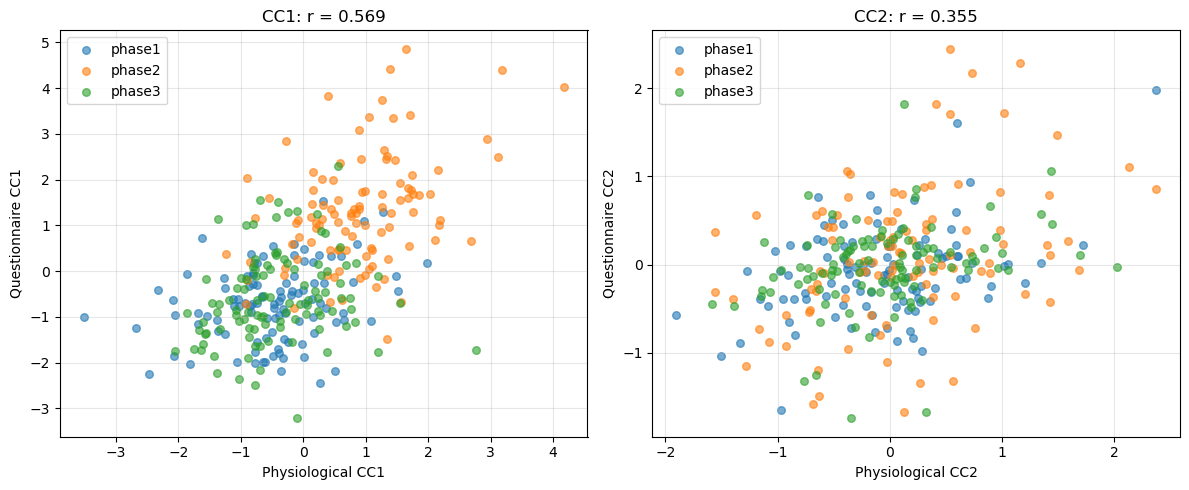

In [19]:
# Visualize first two canonical variate pairs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for k, ax in enumerate(axes):
    for val in np.unique(phase):
        mask = phase == val
        ax.scatter(X_c[mask, k], Y_c[mask, k], label=str(val), alpha=0.6, s=30)
    ax.set(xlabel=f'Physiological CC{k+1}',
           ylabel=f'Questionnaire CC{k+1}',
           title=f'CC{k+1}: r = {canon_corrs[k]:.3f}')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('cca_scatter.png', dpi=150); plt.show()


In [20]:
for name, Y in [('Global z-score', Y_global), ('Per-subject z-score', Y_per_subj)]:
    cca = CCA(n_components=3, max_iter=2000)
    cca.fit(X, Y)
    Xc, Yc = cca.transform(X, Y)
    rs = [np.corrcoef(Xc[:, i], Yc[:, i])[0, 1] for i in range(3)]
    print(f"{name:25s}  CC1={rs[0]:.3f}  CC2={rs[1]:.3f}  CC3={rs[2]:.3f}")

Global z-score             CC1=0.515  CC2=0.365  CC3=0.293
Per-subject z-score        CC1=0.596  CC2=0.403  CC3=0.344


In [ ]:
def diagnose_cca(X, Y, groups, name, n_components=3, n_perm=500, seed=0):
    cca = CCA(n_components=n_components, max_iter=2000)
    cca.fit(X, Y)
    Xc, Yc = cca.transform(X, Y)
    obs = np.array([np.corrcoef(Xc[:, i], Yc[:, i])[0, 1]
                    for i in range(n_components)])

    # Permutation
    rng = np.random.default_rng(seed)
    null = np.full((n_perm, n_components), np.nan)
    for j in range(n_perm):
        perm = rng.permutation(len(Y))
        try:
            cca_p = CCA(n_components=n_components, max_iter=2000)
            cca_p.fit(X, Y[perm])
            Xpc, Ypc = cca_p.transform(X, Y[perm])
            null[j] = [np.corrcoef(Xpc[:, i], Ypc[:, i])[0, 1]
                       for i in range(n_components)]
        except Exception:
            pass
    pvals = np.array([(np.nansum(null[:, i] >= obs[i]) + 1) / (n_perm + 1)
                      for i in range(n_components)])

    # GroupKFold CV
    cv = GroupKFold(n_splits=5)
    test_corrs = []
    for tr, te in cv.split(X, groups=groups):
        cca_cv = CCA(n_components=n_components, max_iter=2000)
        cca_cv.fit(X[tr], Y[tr])
        Xc_te, Yc_te = cca_cv.transform(X[te], Y[te])
        test_corrs.append([np.corrcoef(Xc_te[:, i], Yc_te[:, i])[0, 1]
                           for i in range(n_components)])
    cv_r = np.array(test_corrs)

    print(f"\n=== {name} ===")
    for i in range(n_components):
        sig = '***' if pvals[i] < 0.001 else ('**' if pvals[i] < 0.01 else ('*' if pvals[i] < 0.05 else 'ns'))
        print(f"  CC{i+1}: in-sample r={obs[i]:.3f} | "
              f"perm p={pvals[i]:.4f} {sig} | "
              f"CV r={cv_r[:,i].mean():+.3f}±{cv_r[:,i].std():.3f}")

diagnose_cca(X, Y_global,    groups, 'Global z-score')
diagnose_cca(X, Y_per_subj,  groups, 'Per-subject z-score')


=== Global z-score ===
  CC1: in-sample r=0.515 | perm p=0.0020 ** | CV r=+0.337±0.098
  CC2: in-sample r=0.365 | perm p=0.5529 ns | CV r=+0.108±0.066
  CC3: in-sample r=0.293 | perm p=0.9780 ns | CV r=-0.032±0.075

=== Per-subject z-score ===
  CC1: in-sample r=0.596 | perm p=0.0020 ** | CV r=+0.391±0.099
  CC2: in-sample r=0.403 | perm p=0.0479 * | CV r=+0.002±0.164
  CC3: in-sample r=0.344 | perm p=0.2894 ns | CV r=+0.009±0.154


In [ ]:
cca_ps = CCA(n_components=3, max_iter=2000).fit(X, Y_per_subj)
Xc_ps, Yc_ps = cca_ps.transform(X, Y_per_subj)

x_load_ps = canonical_loadings(X, Xc_ps, PHYS_FEATURES)
y_load_ps = canonical_loadings(Y_per_subj, Yc_ps, QUEST_FEATURES)

compare = pd.DataFrame({
    'Global':     y_load['CC1'],         
    'Per-subject': y_load_ps['CC1'],
})
print("\nQuestionnaire CC1 loadings — Global vs Per-subject:")
print(compare.round(3))

corr_x = np.corrcoef(x_load['CC1'], x_load_ps['CC1'])[0, 1]
corr_y = np.corrcoef(y_load['CC1'], y_load_ps['CC1'])[0, 1]
print(f"\nLoading-pattern correlation across methods:")
print(f"  Physiological CC1: r = {corr_x:.3f}")
print(f"  Questionnaire CC1: r = {corr_y:.3f}")


Questionnaire CC1 loadings — Global vs Per-subject:
            Global  Per-subject
Frustrated   0.620        0.586
upset        0.584        0.513
hostile      0.532        0.395
alert        0.655        0.768
ashamed      0.298        0.368
inspired     0.372        0.536
nervous      0.263        0.259
determined   0.504        0.481
attentive    0.585        0.632
afraid       0.197        0.184
active       0.746        0.794

Loading-pattern correlation across methods:
  Physiological CC1: r = 0.992
  Questionnaire CC1: r = 0.898


## 2.3 UMAP/t-SNE

In [30]:
from sklearn.manifold import TSNE
import umap 

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


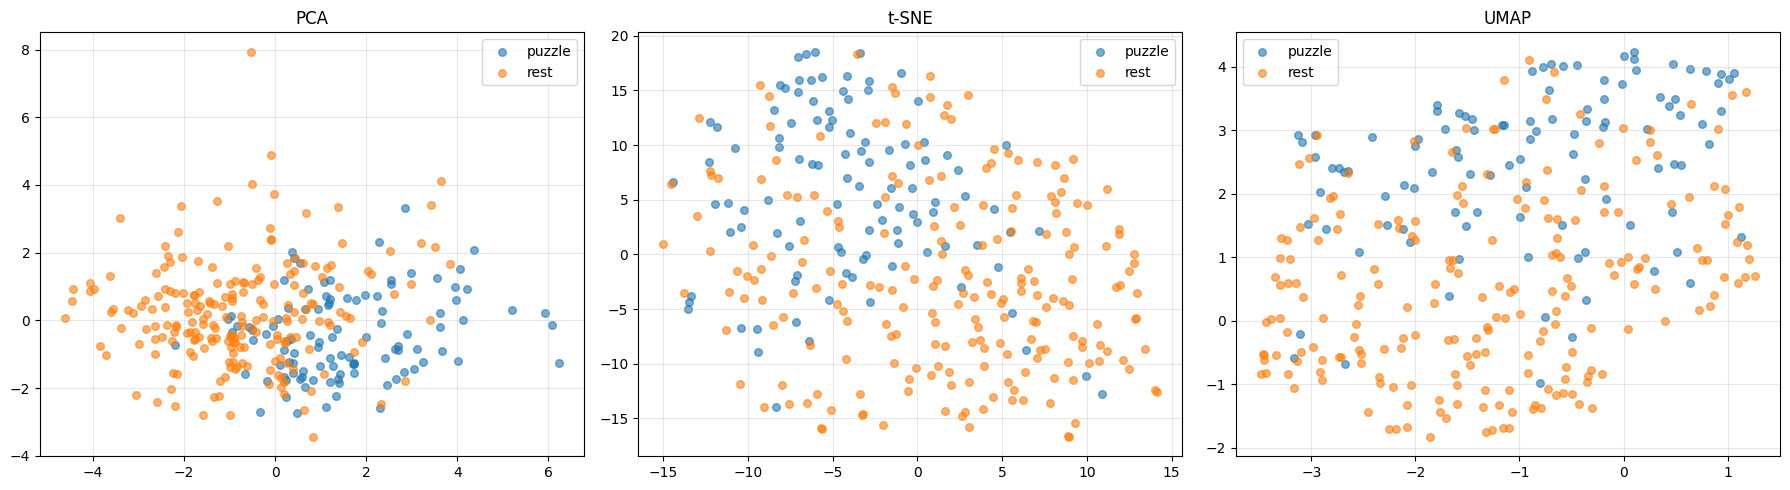


[Manifold] Puzzle vs Rest separation:
  PCA 2D                     silhouette=+0.186   GroupKFold kNN acc=0.792
  t-SNE 2D                   silhouette=+0.135   GroupKFold kNN acc=0.733
  UMAP 2D                    silhouette=+0.173   GroupKFold kNN acc=0.777


(np.float32(0.17337878), np.float64(0.7772222222222223))

In [ ]:
X_for_manifold = X_pca[:, :10]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0, init='pca')
X_tsne = tsne.fit_transform(X_for_manifold)

# UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0)
X_umap = reducer.fit_transform(X_for_manifold)

phase_binary = np.where(phase == 'phase2', 'puzzle', 'rest')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, Z, name in zip(axes, [X_pca[:, :2], X_tsne, X_umap], ['PCA', 't-SNE', 'UMAP']):
    for val in np.unique(phase_binary):
        mask = phase_binary == val
        ax.scatter(Z[mask, 0], Z[mask, 1], label=val, alpha=0.6, s=30)
    ax.set_title(name); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('manifold_comparison.png', dpi=150); plt.show()

print("\n[Manifold] Puzzle vs Rest separation:")
evaluate_representation(X_pca[:, :2], phase_binary, groups, name='PCA 2D')
evaluate_representation(X_tsne,       phase_binary, groups, name='t-SNE 2D')
evaluate_representation(X_umap,       phase_binary, groups, name='UMAP 2D')

# 3. Supplementary analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

In [ ]:
FEATURE_GROUPS = {
    'HR': ['HR_TD_Mean', 'HR_TD_std', 'HR_TD_Slope',
           'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew'],
    'TEMP': ['TEMP_TD_Mean', 'TEMP_TD_Slope', 'TEMP_TD_AUC',
             'TEMP_TD_Kurtosis', 'TEMP_TD_Skew'],
    'EDA_phasic': ['EDA_TD_P_Mean', 'EDA_TD_P_std', 'EDA_TD_P_Slope',
                   'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT',
                   'EDA_TD_P_Skew'],
    'EDA_tonic': ['EDA_TD_T_Mean', 'EDA_TD_T_Slope',
                  'EDA_TD_T_Kurtosis', 'EDA_TD_T_Skew'],
}


In [ ]:
# ============================================================
# 1. Feature-group ablation
# ============================================================
def feature_ablation(df, Y, groups, phase_binary, feature_groups, n_neighbors=5):
    """
    For each feature subset, run PCA -> 2D phase separation,
    and CCA -> CC1 in-sample correlation.
    """
    ablation_sets = {
        'All 22':            sum(feature_groups.values(), []),
        'HR only':           feature_groups['HR'],
        'TEMP only':         feature_groups['TEMP'],
        'EDA-phasic only':   feature_groups['EDA_phasic'],
        'EDA-tonic only':    feature_groups['EDA_tonic'],
        'EDA all':           feature_groups['EDA_phasic'] + feature_groups['EDA_tonic'],
        'No EDA (HR+TEMP)':  feature_groups['HR'] + feature_groups['TEMP'],
    }

    rows = []
    for name, feats in ablation_sets.items():
        X_sub = df[feats].values
        # PCA 2D + binary phase eval
        pca = PCA(n_components=min(2, X_sub.shape[1]))
        Z = pca.fit_transform(X_sub)
        sil = silhouette_score(Z, phase_binary)
        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        cv = GroupKFold(n_splits=5)
        acc = cross_val_score(knn, Z, phase_binary, groups=groups, cv=cv).mean()
        # CCA CC1
        n_comp = min(3, X_sub.shape[1], Y.shape[1])
        cca = CCA(n_components=n_comp, max_iter=2000)
        cca.fit(X_sub, Y)
        Xc, Yc = cca.transform(X_sub, Y)
        cc1 = np.corrcoef(Xc[:, 0], Yc[:, 0])[0, 1]
        rows.append({
            'Feature set': name,
            'n_features': len(feats),
            'PCA-2D silhouette': round(sil, 3),
            'PCA-2D kNN acc': round(acc, 3),
            'CCA CC1 r': round(cc1, 3),
        })
    return pd.DataFrame(rows)


print("=" * 60)
print("1. Feature-group ablation")
print("=" * 60)
ablation_df = feature_ablation(df, Y_per_subj, groups, phase_binary, FEATURE_GROUPS)
print(ablation_df.to_string(index=False))

1. Feature-group ablation
     Feature set  n_features  PCA-2D silhouette  PCA-2D kNN acc  CCA CC1 r
          All 22          22              0.186           0.792      0.596
         HR only           6              0.038           0.633      0.378
       TEMP only           5              0.022           0.574      0.403
 EDA-phasic only           7              0.168           0.736      0.543
  EDA-tonic only           4             -0.023           0.584      0.309
         EDA all          11              0.162           0.772      0.557
No EDA (HR+TEMP)          11              0.067           0.661      0.444


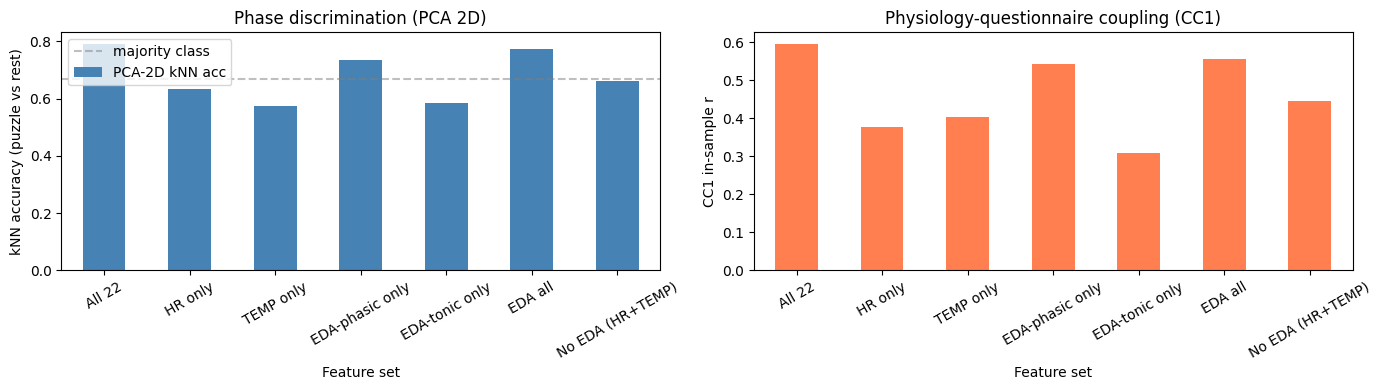

In [ ]:
# Optional bar plot of ablation results
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ablation_df.plot(x='Feature set', y='PCA-2D kNN acc', kind='bar',
                 ax=axes[0], legend=False, color='steelblue')
axes[0].set(ylabel='kNN accuracy (puzzle vs rest)',
            title='Phase discrimination (PCA 2D)')
axes[0].axhline(0.667, ls='--', c='gray', alpha=0.5, label='majority class')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)

ablation_df.plot(x='Feature set', y='CCA CC1 r', kind='bar',
                 ax=axes[1], legend=False, color='coral')
axes[1].set(ylabel='CC1 in-sample r',
            title='Physiology-questionnaire coupling (CC1)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()


2. Loading energy per feature group (top 5 PCs)
              PC1    PC2    PC3    PC4    PC5
HR          0.181  0.274  0.639  0.534  0.047
TEMP        0.079  0.026  0.029  0.207  0.720
EDA_phasic  0.655  0.420  0.249  0.156  0.031
EDA_tonic   0.085  0.280  0.083  0.102  0.202


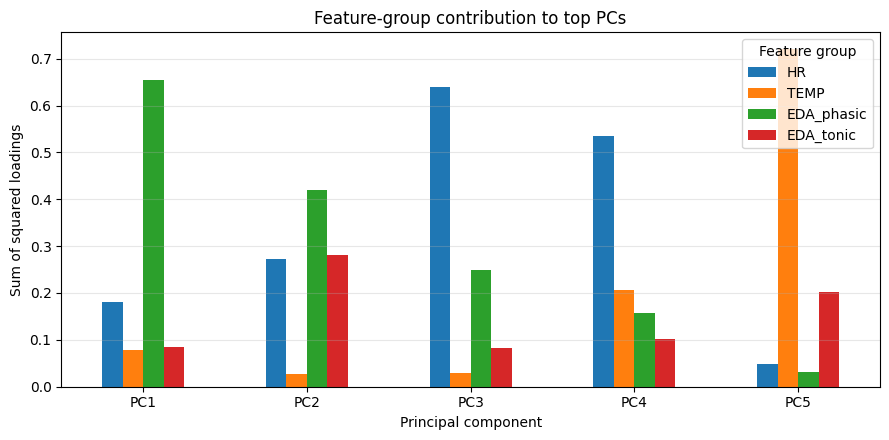

In [ ]:
# ============================================================
# 2. Loading energy bar plot
# ============================================================
def loading_energy(pca_obj, feature_names, feature_groups, n_pcs=5):
    """Sum of squared loadings per feature group per PC."""
    energies = pd.DataFrame(
        index=list(feature_groups.keys()),
        columns=[f'PC{i+1}' for i in range(n_pcs)],
        dtype=float
    )
    for i in range(n_pcs):
        loadings_pc = pca_obj.components_[i]
        for gname, gfeats in feature_groups.items():
            idx = [feature_names.index(f) for f in gfeats]
            energies.loc[gname, f'PC{i+1}'] = float(np.sum(loadings_pc[idx] ** 2))
    return energies


print("\n" + "=" * 60)
print("2. Loading energy per feature group (top 5 PCs)")
print("=" * 60)
pca_full = PCA().fit(X)
energy_df = loading_energy(pca_full, PHYS_FEATURES, FEATURE_GROUPS, n_pcs=5)
print(energy_df.round(3))

# Plot
fig, ax = plt.subplots(figsize=(9, 4.5))
energy_df.T.plot(kind='bar', ax=ax,
                 color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set(xlabel='Principal component',
       ylabel='Sum of squared loadings',
       title='Feature-group contribution to top PCs')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Feature group', loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('loading_energy.png', dpi=150)
plt.show()


3. Subject-block permutation test (n_perm=1000)
  CC1: observed r = 0.596, p = 0.0380 *
  CC2: observed r = 0.403, p = 0.7902 ns
  CC3: observed r = 0.344, p = 0.9171 ns


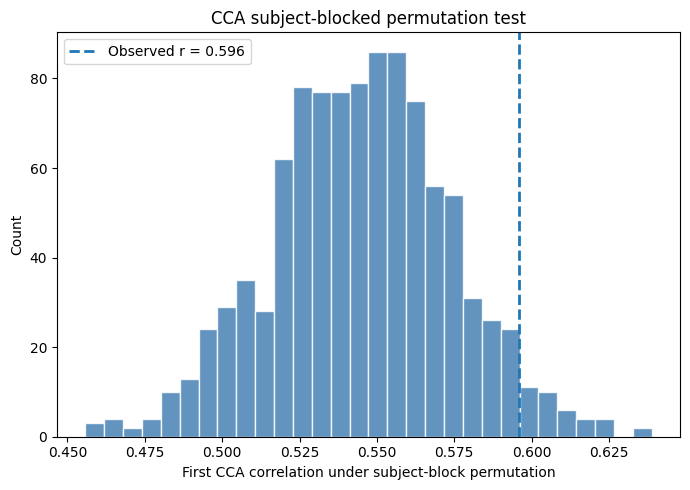

In [ ]:
# ============================================================
# 3. Subject-block permutation test for CCA
# ============================================================
def subject_block_permutation_cca(X, Y, groups, n_components=3,
                                  n_perm=1000, seed=0):
    """
    Subject-level permutation: shuffle subject IDs in Y, keeping each subject's
    12-row block intact. Breaks subject-level X-Y correspondence while
    preserving within-subject structure on the Y side. Stricter than row-level
    permutation because it does not destroy within-subject phase structure.
    """
    rng = np.random.default_rng(seed)
    unique_subj = np.unique(groups)

    # Observed correlations
    cca = CCA(n_components=n_components, max_iter=2000)
    cca.fit(X, Y)
    Xc, Yc = cca.transform(X, Y)
    obs = np.array([np.corrcoef(Xc[:, i], Yc[:, i])[0, 1]
                    for i in range(n_components)])

    null = np.full((n_perm, n_components), np.nan)
    for j in range(n_perm):
        perm_subj = rng.permutation(unique_subj)
        subj_map = dict(zip(unique_subj, perm_subj))
        Y_perm = np.zeros_like(Y)
        for orig_subj in unique_subj:
            mapped_subj = subj_map[orig_subj]
            orig_idx = np.where(groups == orig_subj)[0]
            mapped_idx = np.where(groups == mapped_subj)[0]
            n = min(len(orig_idx), len(mapped_idx))
            Y_perm[orig_idx[:n]] = Y[mapped_idx[:n]]
        try:
            cca_p = CCA(n_components=n_components, max_iter=2000)
            cca_p.fit(X, Y_perm)
            Xpc, Ypc = cca_p.transform(X, Y_perm)
            null[j] = [np.corrcoef(Xpc[:, i], Ypc[:, i])[0, 1]
                       for i in range(n_components)]
        except Exception:
            pass
    pvals = np.array([
        (np.nansum(null[:, i] >= obs[i]) + 1) / (n_perm + 1)
        for i in range(n_components)
    ])
    return obs, pvals, null


print("\n" + "=" * 60)
print("3. Subject-block permutation test (n_perm=1000)")
print("=" * 60)
obs_sb, pvals_sb, null_sb = subject_block_permutation_cca(
    X, Y_per_subj, groups, n_components=3, n_perm=1000
)
for i in range(3):
    sig = '***' if pvals_sb[i] < 0.001 else \
          ('**' if pvals_sb[i] < 0.01 else
           ('*' if pvals_sb[i] < 0.05 else 'ns'))
    print(f"  CC{i+1}: observed r = {obs_sb[i]:.3f}, "
          f"p = {pvals_sb[i]:.4f} {sig}")

# Histogram for CC1 (this is the publication-ready figure)
plt.figure(figsize=(7, 5))
plt.hist(null_sb[:, 0][~np.isnan(null_sb[:, 0])], bins=30,
         color='steelblue', alpha=0.85, edgecolor='white')
plt.axvline(obs_sb[0], ls='--', lw=2, color='C0',
            label=f'Observed r = {obs_sb[0]:.3f}')
plt.xlabel('First CCA correlation under subject-block permutation')
plt.ylabel('Count')
plt.title('CCA subject-blocked permutation test')
plt.legend()
plt.tight_layout()
plt.savefig('cca_subject_block_perm.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# 4. LOSO CCA cross-validation
# ============================================================
def loso_cca(X, Y, groups, n_components=3):
    """
    Leave-one-subject-out CCA.
    Fits on N-1 subjects, projects the held-out subject's X and Y, then
    pools all held-out canonical scores across subjects and computes one
    correlation per component on the pooled scores. This is stricter than
    averaging per-fold correlations, since each held-out subject only has
    12 samples, where r is high-variance.
    """
    unique_subj = np.unique(groups)
    pooled_X = [[] for _ in range(n_components)]
    pooled_Y = [[] for _ in range(n_components)]

    for subj in unique_subj:
        te = groups == subj
        tr = ~te
        cca = CCA(n_components=n_components, max_iter=2000)
        cca.fit(X[tr], Y[tr])
        Xc_te, Yc_te = cca.transform(X[te], Y[te])
        for i in range(n_components):
            pooled_X[i].extend(Xc_te[:, i])
            pooled_Y[i].extend(Yc_te[:, i])

    return np.array([
        np.corrcoef(pooled_X[i], pooled_Y[i])[0, 1]
        for i in range(n_components)
    ])


print("\n" + "=" * 60)
print("4. LOSO CCA (pooled held-out correlation)")
print("=" * 60)
loso_r = loso_cca(X, Y_global, groups, n_components=3)
for i, r in enumerate(loso_r):
    print(f"  CC{i+1}: pooled LOSO r = {r:+.3f}")


4. LOSO CCA (pooled held-out correlation)
  CC1: pooled LOSO r = +0.309
  CC2: pooled LOSO r = +0.055
  CC3: pooled LOSO r = -0.068


In [5]:
df_13 = pd.read_csv('data_13.csv')


In [ ]:

def cv_cca_correlation(X, Y, groups, n_components=3, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)
    test_corrs = []
    for tr, te in cv.split(X, groups=groups):
        cca = CCA(n_components=n_components, max_iter=2000)
        cca.fit(X[tr], Y[tr])
        Xc_te, Yc_te = cca.transform(X[te], Y[te])
        rs = [np.corrcoef(Xc_te[:, i], Yc_te[:, i])[0, 1]
              for i in range(n_components)]
        test_corrs.append(rs)
    return np.array(test_corrs)


for name, X_use, Y_use in [
    ('22 features + per-subject Y', X, Y_per_subj),
    ('13 features + per-subject Y', X_13, Y_per_subj),
    ('13 features + global Y',      X_13, Y_global),
]:
    cv_r = cv_cca_correlation(X_use, Y_use, groups)
    print(f"{name}:")
    print(f"  CC1 5-fold GroupKFold r = {cv_r[:,0].mean():+.3f} ± {cv_r[:,0].std():.3f}")

22 features + per-subject Y:
  CC1 5-fold GroupKFold r = +0.391 ± 0.099
13 features + per-subject Y:
  CC1 5-fold GroupKFold r = +0.441 ± 0.102
13 features + global Y:
  CC1 5-fold GroupKFold r = +0.376 ± 0.137
